In [1]:
from dsa.ms_dsa.Evaluation.binding_interface_eval import BIEvaluation
from dsa.ms_dsa.config import ms_data_relativePath
import warnings
warnings.filterwarnings("ignore")
binding_interface_eval = BIEvaluation(ms_data_relativePath=ms_data_relativePath, cutoff=6.5, lysine_only=True)
#binding_interface_eval.plot_boxplot()

    #binding_interface_eval.plot_dsa_vs_sasa_with_binding_annotation(sasa_type="asa", run_index=run_index)
#binding_interface_eval.plot_dsa_vs_sasa_with_binding_annotation(sasa_type="RelASA", run_index=0)


KeyboardInterrupt: 

In [ ]:
from dsa.binding_interfaces.contacts.structure_contacts import StructureContactsStore
store = StructureContactsStore(database="pdb", distance_cutoff=6.5, contact_filter_key="lysine_only")
#c = store.load("2y0n")
structure_id = "221p"
structure_id = "8ptx"
struct_contacts = store.load(structure_id)
print(struct_contacts)


sum([c.bond_properties.bond_characteristics['hydrogen_bond']['assume_lysine']['exists'] for c in struct_contacts.contacts])

Using biological assembly: '1'
<dsa.binding_interfaces.structure.structure.PDBStructure object at 0x7f887ba02d90>-65-LysineOnlyFilter


361

In [4]:
from dsa.binding_interfaces.contacts.protein_contacts import ProteinContactsStore
store = ProteinContactsStore(structure_database="pdb", distance_cutoff=6.5, contact_filter_key="lysine_only")
#c = store.load("2y0n")
uniprot_id = "Q9NZC9"
uniprot_id = "Q9NXE8"
uniprot_id = "Q93050"
protein_contacts = store.load(uniprot_id)
print(protein_contacts)
protein_contacts.summary_table()
# sum([c.grouped_residues['hydrogen_bond']['assume_lysine']['exists'] for c in struct_contacts.contacts])

Using biological assembly: '1'
Using biological assembly: '1'
Using biological assembly: '1'
Using biological assembly: '1'
Using biological assembly: '1'
Using biological assembly: '1'
Using biological assembly: '1'


count
level_0     level_1                   
intra-chain salt_bridge             17
            hydrogen_bond           24
            covalent_isopeptide      0
            cation_pi               14
            3.0                     21
            3.5                     31
            4.0                     33
            4.5                     35
            5.0                     35
            5.5                     36
            6.0                     36
            6.5                     36
inter-chain salt_bridge              1
            hydrogen_bond            1
            covalent_isopeptide      0
            cation_pi                0
            3.0                      1
            3.5                      1
            4.0                      2
            4.5                      3
            5.0                      3
            5.5                      5
            6.0                      5
            6.5                      5

In [6]:
from dsa.binding_interfaces.contacts.protein_contacts import ProteinContacts, ProteinContactsStore
store = ProteinContactsStore(structure_database="pdb", distance_cutoff=6.5, contact_filter_key="lysine_only")
ct =  store.load("Q92888")
print(ct.residue_groups.keys())
print([k for dct in ct.residue_groups.values() for k in dct.keys()])


AttributeError: 'NoneType' object has no attribute 'residue_groups'

In [1]:
from dsa.binding_interfaces.mappings.uniprot_mappings import UniprotStructureMappingsStore
from dsa.binding_interfaces.structure.structure import Structure, PDBStructure
import re
PDB_STRUCTURES_TO_PROCESS = UniprotStructureMappingsStore("pdb").get_mapper().get_mapped_structures()
subchains = {}

def summary(structure):
    chains = set(chain.name for chain in structure.model.model)
    subchains = set(residue.subchain for chain in structure.model.model for residue in chain)
    bio_chains = set(chain.name for chain in structure.bio_model.model)
    bio_subchains = set(residue.subchain for chain in structure.bio_model.model for residue in chain)
    print(f"Chains: {chains}")
    print(f"Subchains: {subchains}")
    print(f"Bio Chains: {bio_chains}")
    print(f"Bio Subchains: {bio_subchains}")
    

for i, structure_id in enumerate(PDB_STRUCTURES_TO_PROCESS):
    try:
        structure = PDBStructure(structure_id)
        subchains = structure.model.subchain_ids
        if len(subchains) != len(set(subchains)):
            print(structure_id)
            print(subchains)
            print(set(subchains))
        subchains = set(subchains)
        bio_subchains = structure.bio_model.subchain_ids
        if len(bio_subchains) != len(set(bio_subchains)):
            print(structure_id)
            print(bio_subchains)
            print(set(bio_subchains))
        bio_subchains = set(bio_subchains)
        stripped_bio_subchains = set([re.sub(r'\d+', '', bc) for bc in bio_subchains])
        #assert len(stripped_bio_subchains) == len(subchains)
        if stripped_bio_subchains.intersection(subchains) != stripped_bio_subchains:
            print(structure_id)
            print(subchains)
            print(stripped_bio_subchains)
        has_digits = any([bool(re.search(r"\d", s)) for s in subchains])
        if has_digits:
            print(structure_id)
        if i % 1000 == 0:
            print(f"Processed {i} structures")
    except Exception as e:
        #print(f"Error loading structure {structure_id}: {e}")
        continue
#subchains = {structure_id:  PDBStructure(structure_id).model.subchain_ids for structure_id in PDB_STRUCTURES_TO_PROCESS}
# subchains_has_digits = {structure_id: any([bool(re.search(r"\d", s)) for s in subchains[structure_id]]) for structure_id in PDB_STRUCTURES_TO_PROCESS}
# print(sum[subchains_has_digits.values()])


Processed 0 structures


/home/shajain/DynamicSurfaceAccessibility/src/dsa/misc/store.py:64: UserWarning: Error loading file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/9a9s.cif: [Errno 2] unable to open() file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/9a9s.cif for reading: No such file or directory
  warnings.warn(f"Error loading file {file_path}: {e}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/misc/store.py:64: UserWarning: Error loading file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/9a0k.cif: [Errno 2] unable to open() file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/9a0k.cif for reading: No such file or directory
  warnings.warn(f"Error loading file {file_path}: {e}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/misc/store.py:64: UserWarning: Error loading file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/9a1v.cif: [Errno 2] unable to open() file /home/shajain/Dy

Processed 1000 structures


/home/shajain/DynamicSurfaceAccessibility/src/dsa/misc/store.py:64: UserWarning: Error loading file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/8zzn.cif: [Errno 2] unable to open() file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/8zzn.cif for reading: No such file or directory
  warnings.warn(f"Error loading file {file_path}: {e}")


Processed 2000 structures


...

/home/shajain/DynamicSurfaceAccessibility/src/dsa/misc/store.py:64: UserWarning: Error loading file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/8zzq.cif: [Errno 2] unable to open() file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/8zzq.cif for reading: No such file or directory
  warnings.warn(f"Error loading file {file_path}: {e}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/misc/store.py:64: UserWarning: Error loading file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/9a0x.cif: [Errno 2] unable to open() file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/9a0x.cif for reading: No such file or directory
  warnings.warn(f"Error loading file {file_path}: {e}")


Processed 35000 structures


/home/shajain/DynamicSurfaceAccessibility/src/dsa/misc/store.py:64: UserWarning: Error loading file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/9a05.cif: [Errno 2] unable to open() file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/9a05.cif for reading: No such file or directory
  warnings.warn(f"Error loading file {file_path}: {e}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/misc/store.py:64: UserWarning: Error loading file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/8zz4.cif: [Errno 2] unable to open() file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/8zz4.cif for reading: No such file or directory
  warnings.warn(f"Error loading file {file_path}: {e}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/misc/store.py:64: UserWarning: Error loading file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/9a3o.cif: [Errno 2] unable to open() file /home/shajain/Dy

Processed 36000 structures
Processed 37000 structures


/home/shajain/DynamicSurfaceAccessibility/src/dsa/misc/store.py:64: UserWarning: Error loading file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/8zzf.cif: [Errno 2] unable to open() file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/8zzf.cif for reading: No such file or directory
  warnings.warn(f"Error loading file {file_path}: {e}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/misc/store.py:64: UserWarning: Error loading file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/9a3y.cif: [Errno 2] unable to open() file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/structures/pdb/9a3y.cif for reading: No such file or directory
  warnings.warn(f"Error loading file {file_path}: {e}")


In [5]:
import re
bool(re.search(r"\d", '1aa'))

True

In [2]:
from dsa.binding_interfaces.contacts.structure_contacts import StructureContacts, StructureContactsStore

struct_contacts = StructureContactsStore(database="pdb", distance_cutoff=6.5, contact_filter_key="lysine_only").load("3s8s")
bad_contacts = [c for c in struct_contacts.contacts if c.atom1 is None or c.atom2 is None]
print(len(bad_contacts))
bad_contact = bad_contacts[0]
print(bad_contact.chain1.name, bad_contact.residue1.seqid, bad_contact.atom1)
print(bad_contact.chain2.name, bad_contact.residue2.seqid, bad_contact.atom2)
print(bad_contact.dist)
print(len(struct_contacts.contacts))

struct_contacts = StructureContacts("3s8s","pdb",6.5,"lysine_only")
print(len(struct_contacts.contacts))
bad_contact2 = [c for c in struct_contacts.contacts if c.chain1.name == bad_contact.chain1.name and c.residue1.name == bad_contact.residue1.name and c.chain2.name == bad_contact.chain2.name and c.residue2.name == bad_contact.residue2.name]
print(len(bad_contact2))
print(bad_contact2[0].chain1.name, bad_contact2[0].residue1.seqid, bad_contact2[0].atom1.name)
print(bad_contact2[0].chain2.name, bad_contact2[0].residue2.seqid, bad_contact2[0].atom2)
print(bad_contact2[0].dist)
print(bad_contact2[0].__getstate__())

st = struct_contacts.structure
bad_contact_state = bad_contact2[0].__getstate__()

c1,r1,a1 = st.get_bio_chain_residue_atom_objects(bad_contact_state["chain1"], bad_contact_state["residue1"], bad_contact_state["atom1"])
c2,r2,a2 = st.get_bio_chain_residue_atom_objects(bad_contact_state["chain2"], bad_contact_state["residue2"], bad_contact_state["atom2"])

print(c1,r1,a1)
print(c2,r2,a2)





Using biological assembly: '1'
38
A1 91 <gemmi.Atom CD1 at (-0.6, 23.3, 10.8)>
A1 172 None
5.953861688013921
65
Using biological assembly: '1'
65
1
A1 91 CD1
A1 172 <gemmi.Atom NZ.A at (0.1, 24.9, 5.1)>
5.953861688013921
{'structure': <dsa.binding_interfaces.structure.structure.PDBStructure object at 0x7fafe5dccd90>, 'chain1': 'A1', 'residue1': ('91', 'ILE', 'I'), 'atom1': 'CD1', 'chain2': 'A1', 'residue2': ('172', 'LYS', 'K'), 'atom2': 'NZ', 'dist': 5.953861688013921, 'properties1': {'is_amino_acid': True, 'is_nucleotide': False, 'is_water': False, 'is_standard': True, 'is_polymer': True, 'is_lysine': False, 'is_ptm': False, 'is_ligand': False}, 'properties2': {'is_amino_acid': True, 'is_nucleotide': False, 'is_water': False, 'is_standard': True, 'is_polymer': True, 'is_lysine': True, 'is_ptm': False, 'is_ligand': False}, 'bond_properties': {'covalent_isopeptide': {'exists': False, 'residue1_as_lysine': {'exists': False}, 'residue2_as_lysine': {'exists': False, 'info': []}}, 'cation_p

In [1]:
import matplotlib.pyplot as plt
def histograms(ms_dsa, strict: bool=True, run_index: int=None):
    ms_dsa = ms_dsa[ms_dsa["skipped"] == False]
    if strict:
        inter = ms_dsa[ms_dsa["is_strictly_inter_chain_contact_pdb"]]
    else:
        inter = ms_dsa[ms_dsa["is_inter_chain_contact_pdb"]]
    print(f"Inter: {inter.shape}")
    # intra_pdb = ms_dsa[ms_dsa["is_intra_chain_contact_pdb"]]
    intra_AF = ms_dsa[ms_dsa["is_intra_chain_contact_AF"]]
    #intra = ms_dsa[ms_dsa["is_intra_chain_contact_pdb"]]
    intra = intra_AF
    print(f"Intra: {intra.shape}")
    not_contact = ms_dsa[~ms_dsa["is_inter_chain_contact_pdb"] & ~ms_dsa["is_intra_chain_contact"]]
    plt.hist(inter["MS_DSA"].values, bins=10, label="Inter", alpha=0.25, density=True)
    plt.hist(intra["MS_DSA"].values, bins=10, label="Intra", alpha=0.25, density=True)
    plt.hist(not_contact["MS_DSA"].values, bins=10, label="Not Contact", alpha=0.25, density=True)
    plt.xlabel("MS_DSA")
    plt.ylabel("Frequency")
    plt.title("MS_DSA Distribution on Run {run_index}")
    plt.legend()
    plt.show()

def plot_dsa_vs_sasa_with_binding_annotation(ms_dsa, sasa_type: str="asa_nz", statistic: str="avg", strict: bool=True, run_index: int=None):
        ms_dsa = ms_dsa[ms_dsa["skipped"] == False]
        sasa_column = f"{sasa_type}_{statistic}"
        if strict:
            inter = ms_dsa[ms_dsa["is_strictly_inter_chain_contact_pdb"]]
        else:
            inter = ms_dsa[ms_dsa["is_inter_chain_contact_pdb"]]
        print(f"Inter: {inter.shape}")
        print(f"% of Inter less than 0.9: {len(inter[inter['MS_DSA'] < 0.9]) / len(inter)}")
        #not_inter = self.combined_df[~self.combined_df["is_inter_chain_contacts"]]
        intra_pdb = ms_dsa[ms_dsa["is_intra_chain_contact_pdb"]]
        print(f"Intra: {intra_pdb.shape}")
        print(f"% of Intra less than 0.9: {len(intra_pdb[intra_pdb['MS_DSA'] < 0.9]) / len(intra_pdb)}")
        intra_AF = ms_dsa[ms_dsa["is_intra_chain_contact_AF"]]
        print(f"Intra AF: {intra_AF.shape}")
        print(f"% of Intra AF less than 0.9: {len(intra_AF[intra_AF['MS_DSA'] < 0.9]) / len(intra_AF)}")
        #intra = ms_dsa[ms_dsa["is_intra_chain_contact"]]
        intra = intra_AF
        # print(f"Intra: {intra.shape}")
        # print(f"% of Intra less than 0.9: {len(intra[intra['MS_DSA'] < 0.9]) / len(intra)}")
        not_contact = ms_dsa[~ms_dsa["is_inter_chain_contact_pdb"] & ~ms_dsa["is_intra_chain_contact"]]
        print(f"Not Contact: {not_contact.shape}")
        print(f"% of Not Contact less than 0.9: {len(not_contact[not_contact['MS_DSA'] < 0.9]) / len(not_contact)}")
        plt.scatter(not_contact["MS_DSA"].values, not_contact[sasa_column].values, color="black", label="Not Contact", s=10, alpha=0.5)
        # plt.scatter(not_inter["MS_DSA"].dropna().values, not_inter["RelASA"].dropna().values, color="black", label="Not Inter")
        plt.scatter(intra["MS_DSA"].values, intra[sasa_column].values, color="green", label="Intra", s=10, alpha=0.5)
        # plt.scatter(not_intra["MS_DSA"].dropna().values, not_intra["RelASA"].dropna().values, color="black", label="Not Intra")
        plt.scatter(inter["MS_DSA"].values, inter[sasa_column].values, color="red", label="Inter", s=10, alpha=0.5)
        plt.xlabel("MS_DSA")
        plt.ylabel(sasa_column)
        plt.title(f"MS_DSA vs {sasa_column} on Run {run_index}")
        plt.legend()
        plt.show()



Inter: (21, 28)
% of Inter less than 0.9: 0.047619047619047616
Intra: (4287, 28)
% of Intra less than 0.9: 0.07137858642407278
Intra AF: (6045, 28)
% of Intra AF less than 0.9: 0.06947890818858561
Not Contact: (7120, 28)
% of Not Contact less than 0.9: 0.07359550561797752


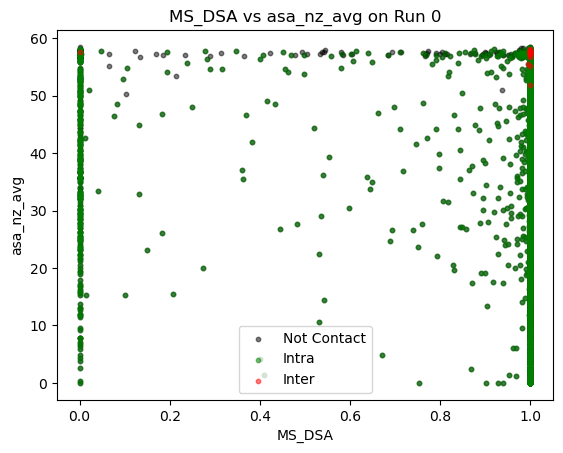

Inter: (21, 28)
Intra: (6045, 28)


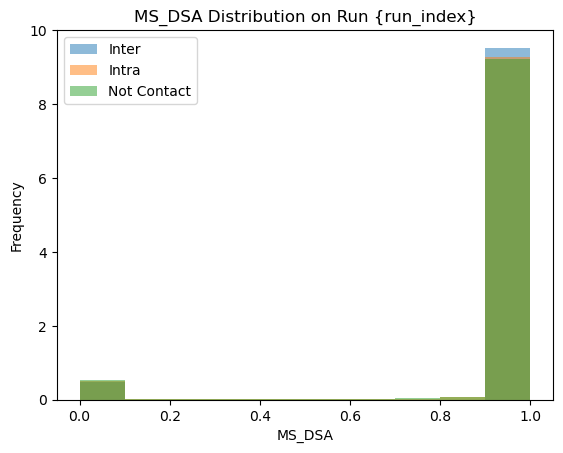

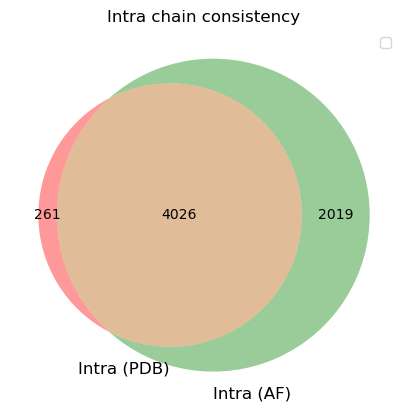

Inter: (17, 28)
% of Inter less than 0.9: 0.11764705882352941
Intra: (3695, 28)
% of Intra less than 0.9: 0.07658998646820027
Intra AF: (5225, 28)
% of Intra AF less than 0.9: 0.08095693779904306
Not Contact: (6138, 28)
% of Not Contact less than 0.9: 0.08178559791463018


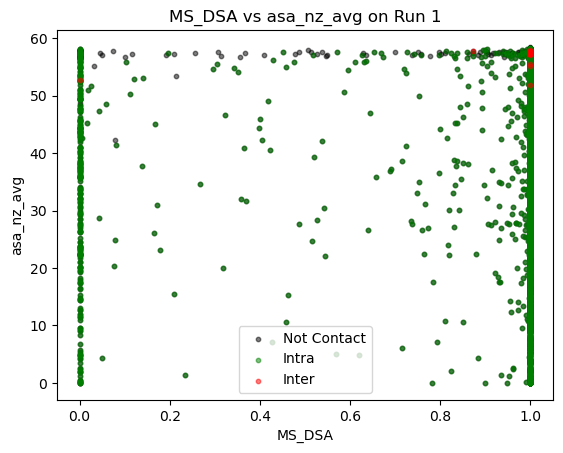

Inter: (17, 28)
Intra: (5225, 28)


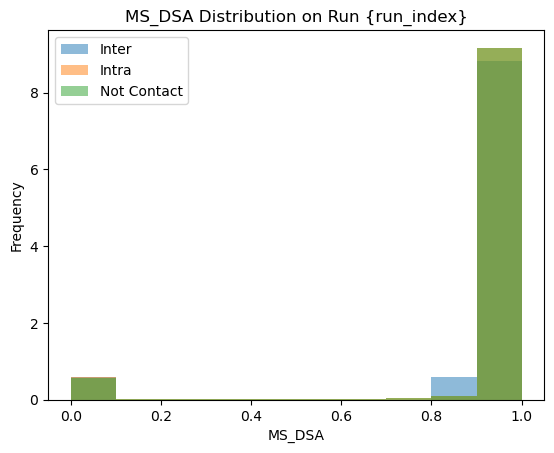

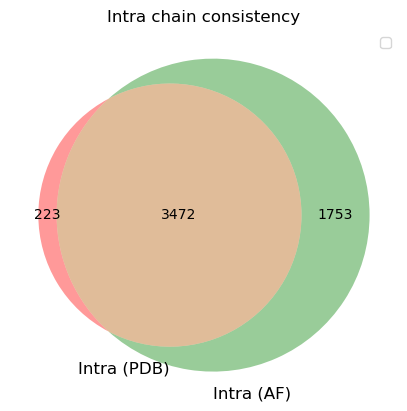

Inter: (22, 28)
% of Inter less than 0.9: 0.13636363636363635
Intra: (4472, 28)
% of Intra less than 0.9: 0.06574239713774598
Intra AF: (6285, 28)
% of Intra AF less than 0.9: 0.06523468575974542
Not Contact: (7377, 28)
% of Not Contact less than 0.9: 0.06967602006235597


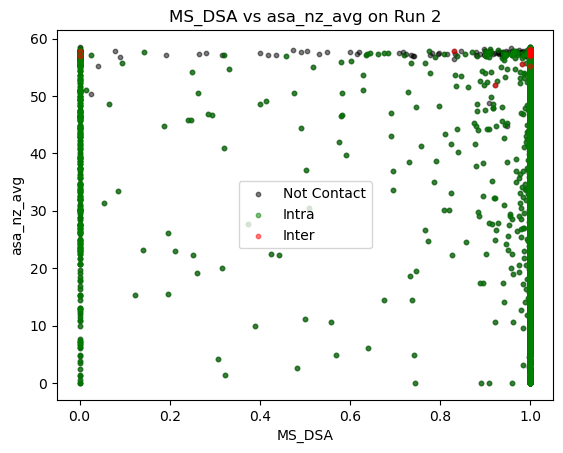

Inter: (22, 28)
Intra: (6285, 28)


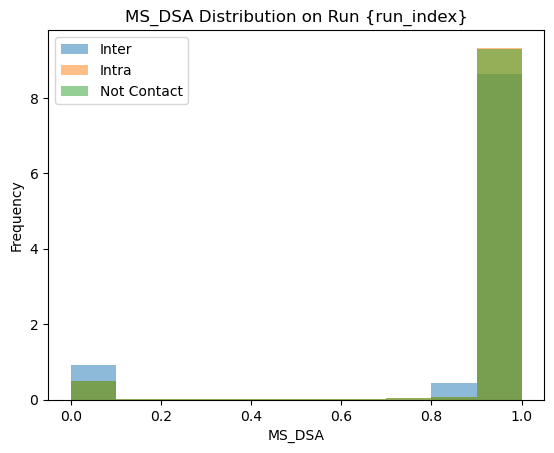

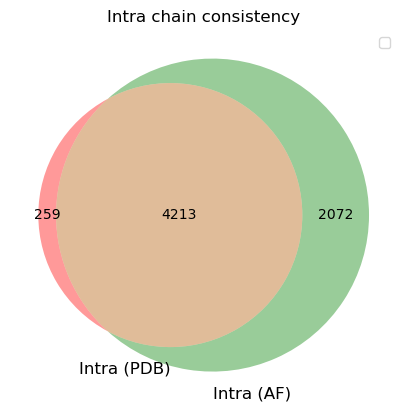

Inter: (18, 28)
% of Inter less than 0.9: 0.05555555555555555
Intra: (4346, 28)
% of Intra less than 0.9: 0.0800736309249885
Intra AF: (6097, 28)
% of Intra AF less than 0.9: 0.08266360505166476
Not Contact: (7122, 28)
% of Not Contact less than 0.9: 0.08410558831788824


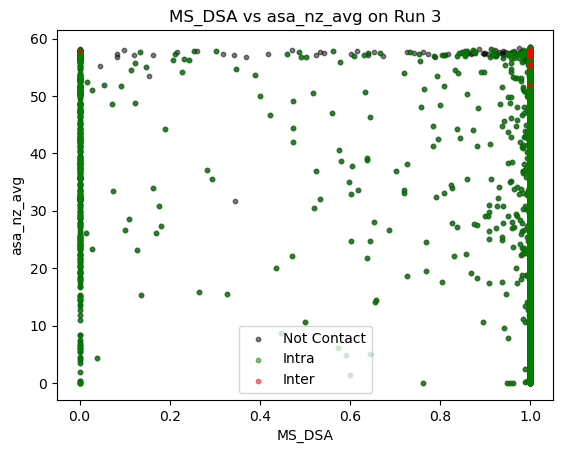

Inter: (18, 28)
Intra: (6097, 28)


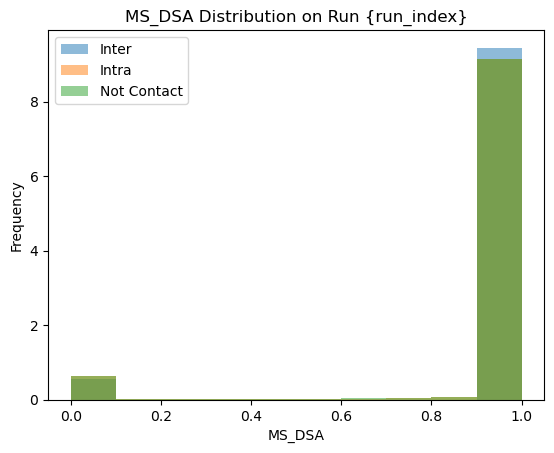

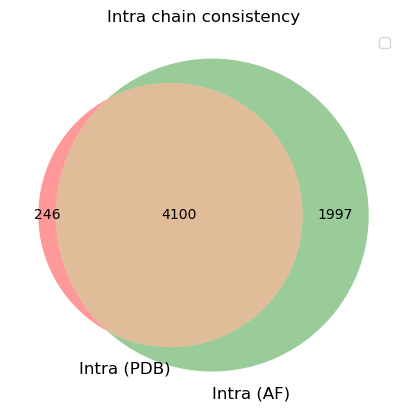

Inter: (20, 28)
% of Inter less than 0.9: 0.1
Intra: (4129, 28)
% of Intra less than 0.9: 0.0646645676919351
Intra AF: (5808, 28)
% of Intra AF less than 0.9: 0.06869834710743801
Not Contact: (6823, 28)
% of Not Contact less than 0.9: 0.06844496555767257


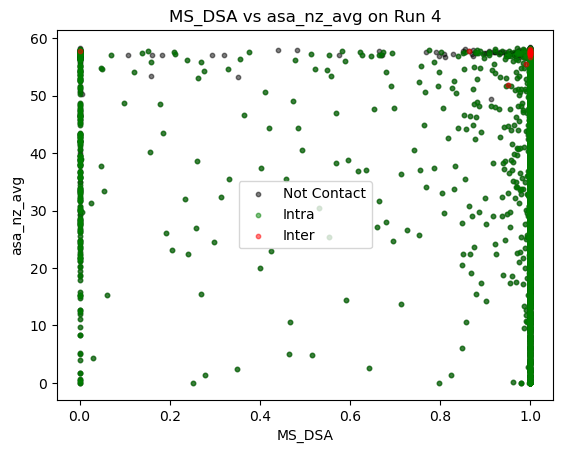

Inter: (20, 28)
Intra: (5808, 28)


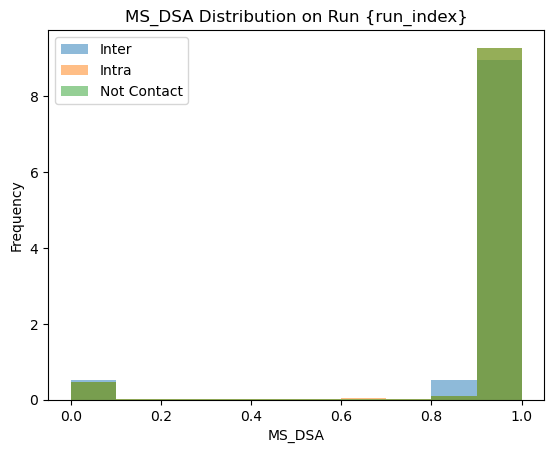

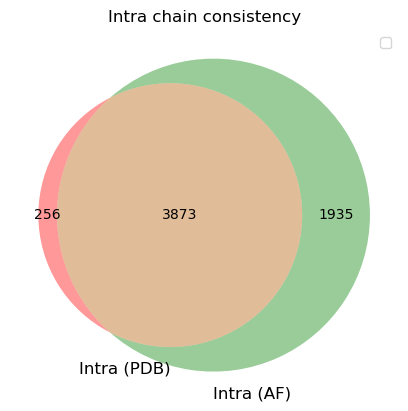

In [13]:
for run_index in binding_interface_eval.run_indices:
    ms_dsa = binding_interface_eval.ms_dsa_by_run[run_index]
    plot_dsa_vs_sasa_with_binding_annotation(ms_dsa, sasa_type="asa_nz", strict=True, run_index=run_index)
    histograms(ms_dsa, strict=True, run_index=run_index)
    binding_interface_eval.intra_chain_consistency(run_index=run_index)

Inter: (1896, 28)
% of Inter less than 0.9: 0.06118143459915612
Intra: (4287, 28)
% of Intra less than 0.9: 0.07137858642407278
Intra AF: (6045, 28)
% of Intra AF less than 0.9: 0.06947890818858561
Not Contact: (7120, 28)
% of Not Contact less than 0.9: 0.07359550561797752


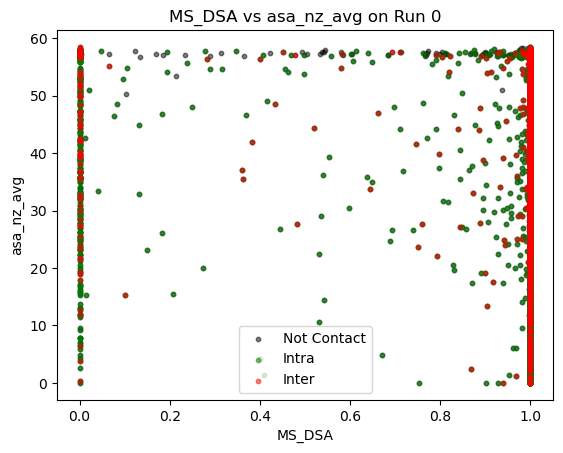

Inter: (1896, 28)
Intra: (6045, 28)


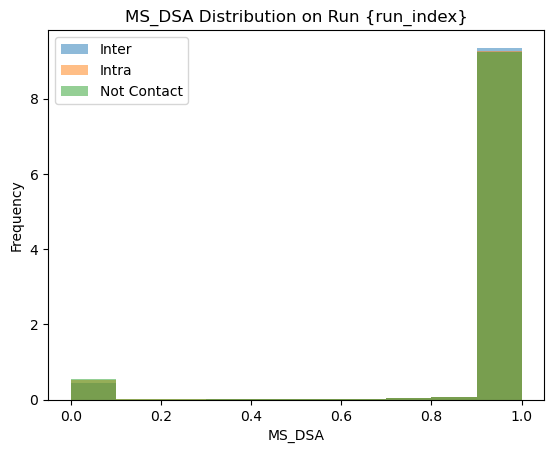

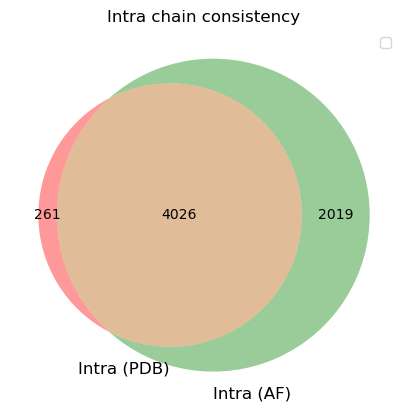

Inter: (1596, 28)
% of Inter less than 0.9: 0.06265664160401002
Intra: (3695, 28)
% of Intra less than 0.9: 0.07658998646820027
Intra AF: (5225, 28)
% of Intra AF less than 0.9: 0.08095693779904306
Not Contact: (6138, 28)
% of Not Contact less than 0.9: 0.08178559791463018


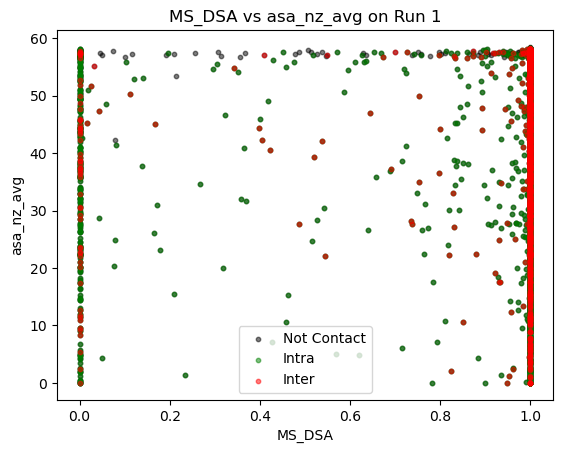

Inter: (1596, 28)
Intra: (5225, 28)


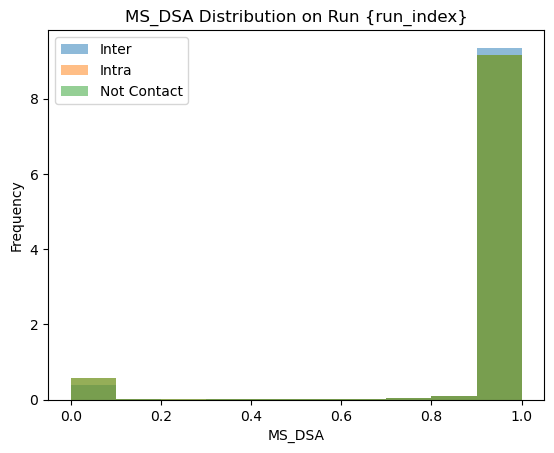

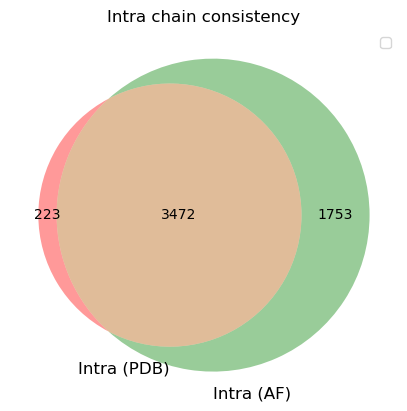

Inter: (1978, 28)
% of Inter less than 0.9: 0.057633973710819006
Intra: (4472, 28)
% of Intra less than 0.9: 0.06574239713774598
Intra AF: (6285, 28)
% of Intra AF less than 0.9: 0.06523468575974542
Not Contact: (7377, 28)
% of Not Contact less than 0.9: 0.06967602006235597


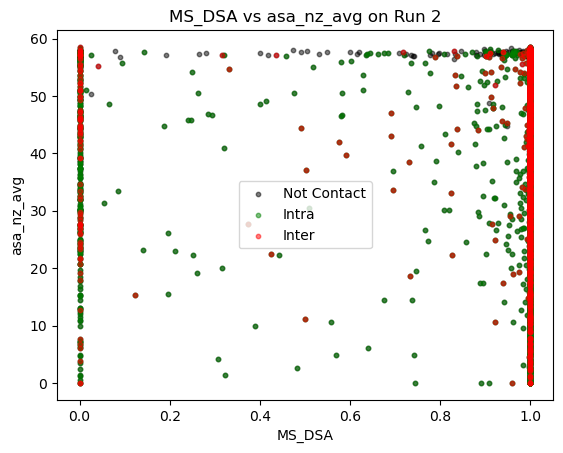

Inter: (1978, 28)
Intra: (6285, 28)


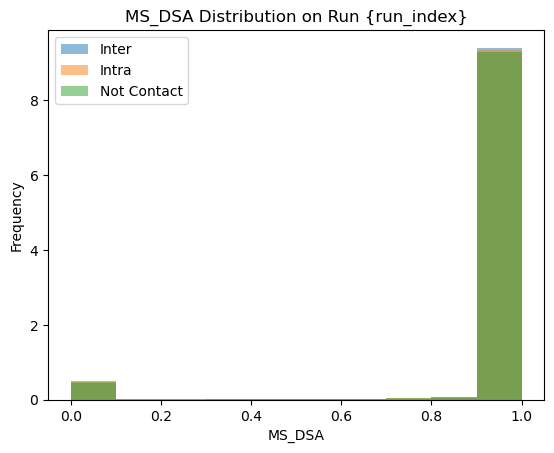

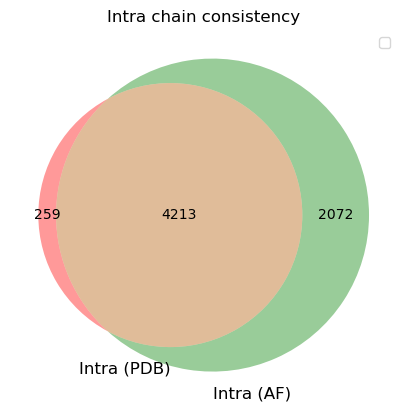

Inter: (1847, 28)
% of Inter less than 0.9: 0.0768814293448836
Intra: (4346, 28)
% of Intra less than 0.9: 0.0800736309249885
Intra AF: (6097, 28)
% of Intra AF less than 0.9: 0.08266360505166476
Not Contact: (7122, 28)
% of Not Contact less than 0.9: 0.08410558831788824


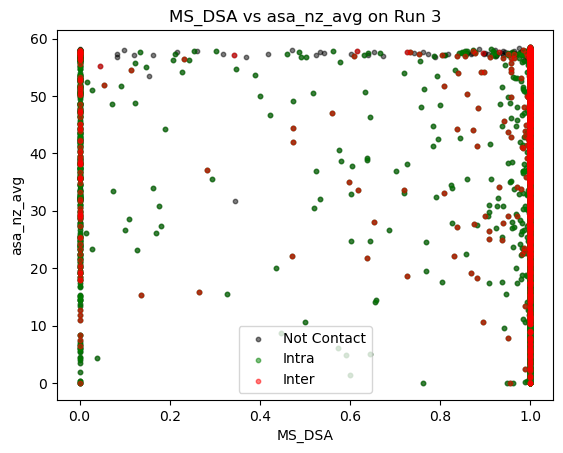

Inter: (1847, 28)
Intra: (6097, 28)


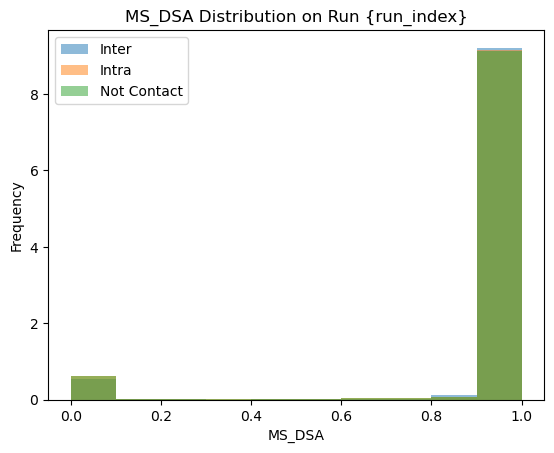

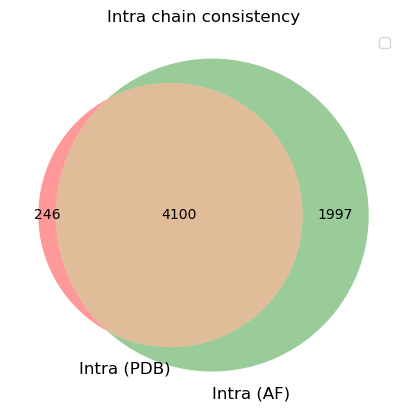

Inter: (1793, 28)
% of Inter less than 0.9: 0.05688789737869492
Intra: (4129, 28)
% of Intra less than 0.9: 0.0646645676919351
Intra AF: (5808, 28)
% of Intra AF less than 0.9: 0.06869834710743801
Not Contact: (6823, 28)
% of Not Contact less than 0.9: 0.06844496555767257


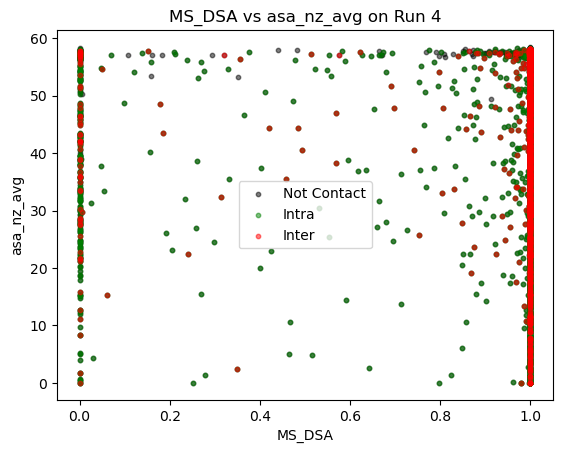

Inter: (1793, 28)
Intra: (5808, 28)


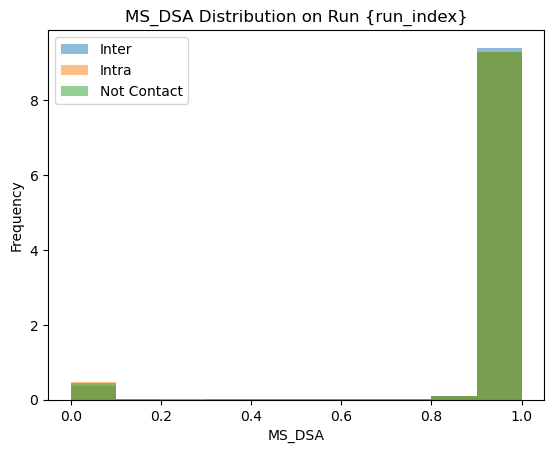

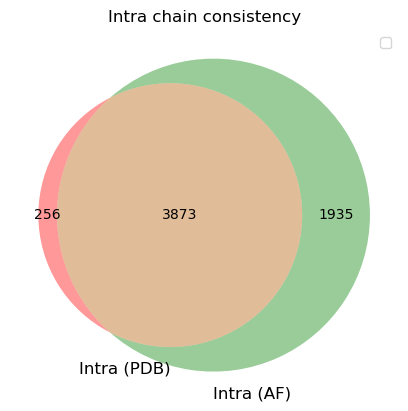

In [14]:
for run_index in binding_interface_eval.run_indices:
    ms_dsa = binding_interface_eval.ms_dsa_by_run[run_index]
    plot_dsa_vs_sasa_with_binding_annotation(ms_dsa, sasa_type="asa_nz", strict=False, run_index=run_index)
    histograms(ms_dsa, strict=False, run_index=run_index)
    binding_interface_eval.intra_chain_consistency(run_index=run_index)

Light areas: [1.0892279e+06 6.5012175e+05]
Heavy areas: []
Light areas: [694465.5 568229.8]
Heavy areas: []
Light areas: [2.1140406e+05 1.1322484e+07]
Heavy areas: []
Light areas: [2.0328170e+06 4.2146475e+05]
Heavy areas: []
Light areas: [ 25886.75 972274.56]
Heavy areas: []
Light areas: [ 52297.51 671443.56]
Heavy areas: []
Light areas: [ 37075.03 886167.75]
Heavy areas: []
Light areas: [1.3413667e+07 1.5047816e+08]
Heavy areas: []
Light areas: [1.4799316e+07 1.4026414e+08]
Heavy areas: []
Light areas: [1.1052100e+07 1.2181825e+08]
Heavy areas: []
Light areas: [9.746569e+06 9.370099e+07]
Heavy areas: []
Light areas: [1.11773980e+07 1.09364584e+08]
Heavy areas: []
Light areas: [1.2974456e+06 4.7905288e+07]
Heavy areas: []
Light areas: [1.144618e+06 3.761463e+07]
Heavy areas: []
Light areas: [9.4674569e+05 3.8011852e+07]
Heavy areas: []
Light areas: [1.0871565e+06 3.1469960e+07]
Heavy areas: []
Light areas: [7.0026950e+05 2.8175164e+07]
Heavy areas: []
Light areas: [3.2072228e+06 3.816

/home/shajain/DynamicSurfaceAccessibility/src/dsa/ms_dsa/ms_dsa.py:64: RuntimeWarning: invalid value encountered in scalar divide
  dsa = light_sum / (light_sum + heavy_sum)


Light areas: []
Heavy areas: [1.2315460e+06 1.2885959e+07]
Light areas: []
Heavy areas: [9.4205912e+05 1.8026262e+07]
Light areas: [1.8350117e+05 1.4384035e+06]
Heavy areas: []
Light areas: [1.882434e+05 1.069741e+06]
Heavy areas: []
Light areas: [5.0069097e+05 3.8527110e+06]
Heavy areas: [0.]
Light areas: [2.5924909e+05 2.7501335e+06]
Heavy areas: []
Light areas: [3.1473591e+05 2.7044792e+06]
Heavy areas: []
Light areas: [1.4636112e+05 2.1786150e+06]
Heavy areas: []
Light areas: [3.3929475e+05 2.8866688e+06]
Heavy areas: []
Light areas: [3.6557508e+06 2.7878508e+06]
Heavy areas: [0.0000000e+00 2.9953956e+07]
Light areas: [2.2954490e+06 1.5596422e+06]
Heavy areas: [0.000000e+00 2.144974e+07]
Light areas: [2.1894748e+06 1.5424891e+06]
Heavy areas: [9.8784531e+04 1.6872652e+07]
Light areas: [3.0941958e+06 1.8256434e+06]
Heavy areas: [0.0000000e+00 1.9376712e+07]
Light areas: [2.1106095e+06 9.9783362e+05]
Heavy areas: [0.0000000e+00 1.3901695e+07]
Light areas: [4.8577790e+06 1.1033553e+05

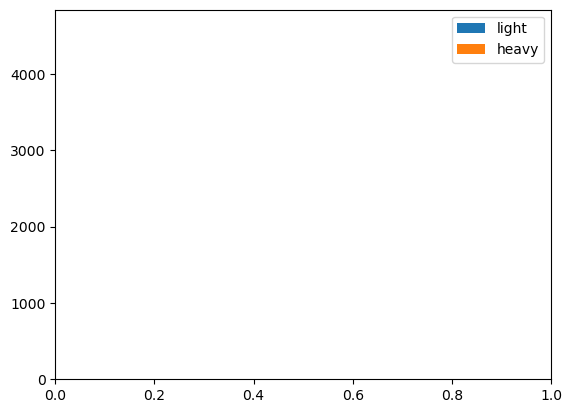

In [2]:
from dsa.ms_dsa.ms_dsa import MS_DSA_Builder, plot_light_heavy_areas
from dsa.ms_dsa.config import ms_data_relativePath
ms_dsa = MS_DSA_Builder(ms_data_relativePath=ms_data_relativePath)
plot_light_heavy_areas(ms_dsa.light_areas, ms_dsa.heavy_areas)



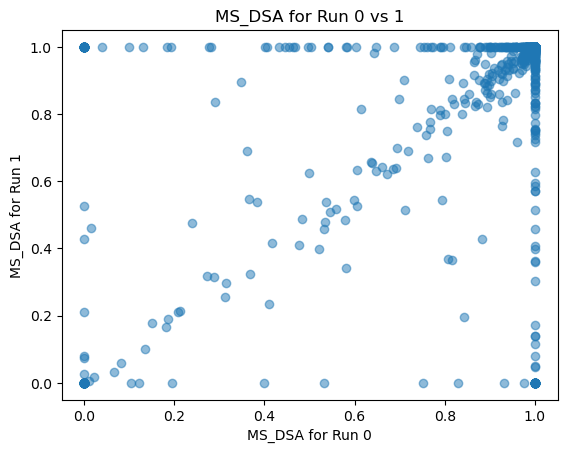

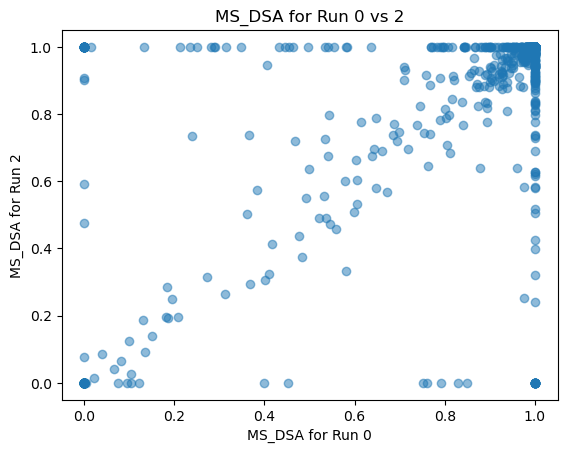

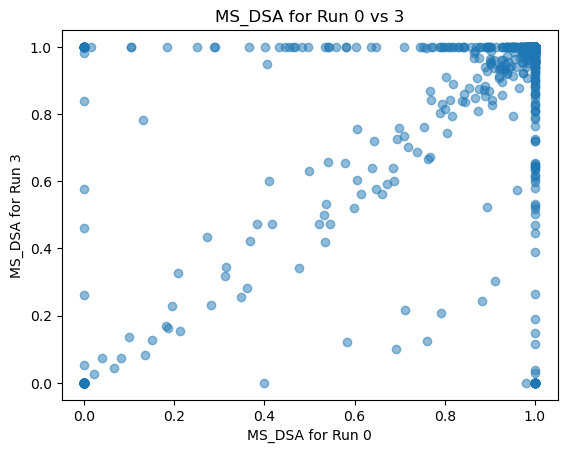

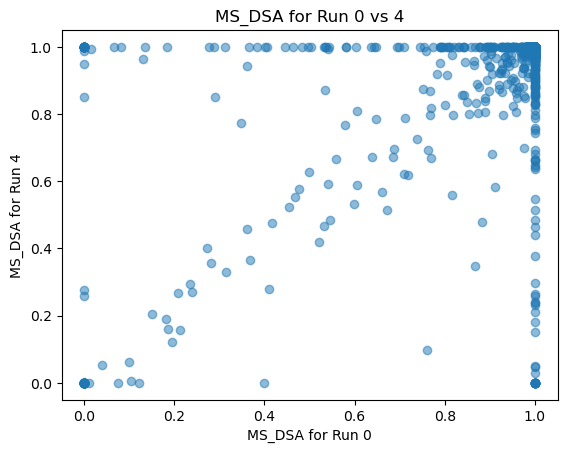

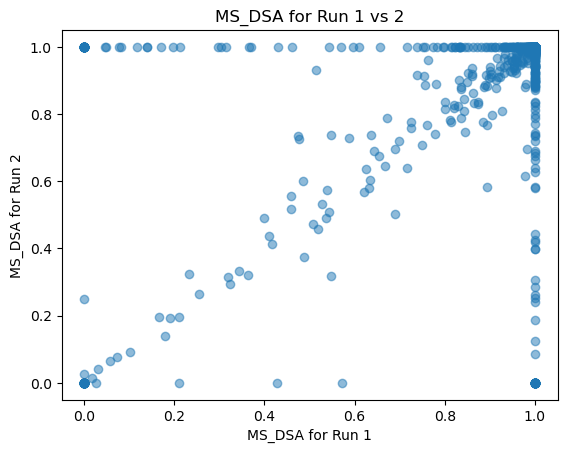

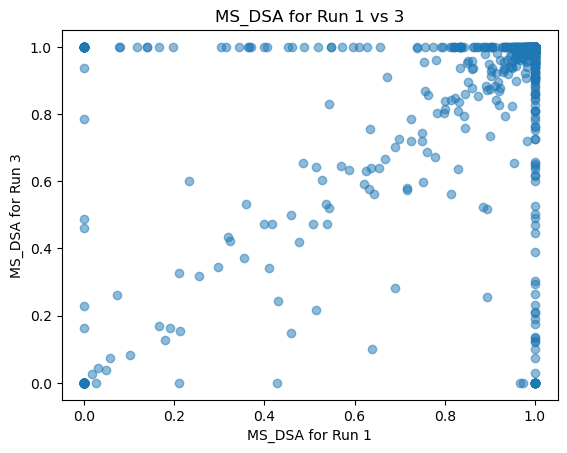

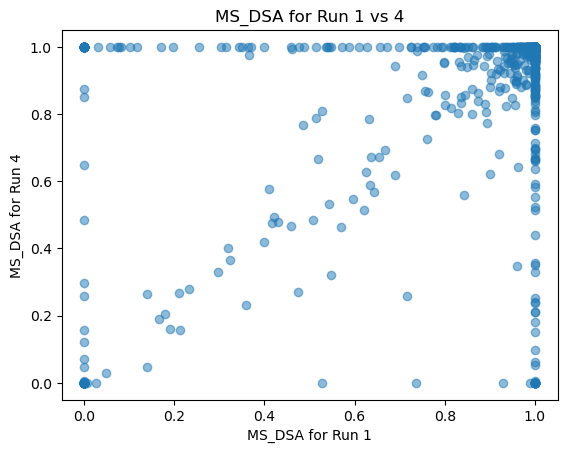

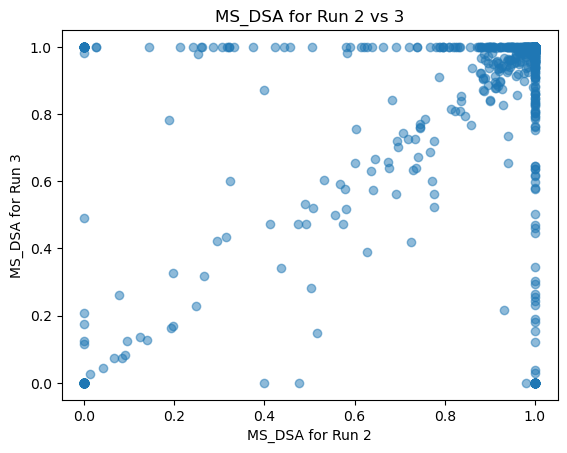

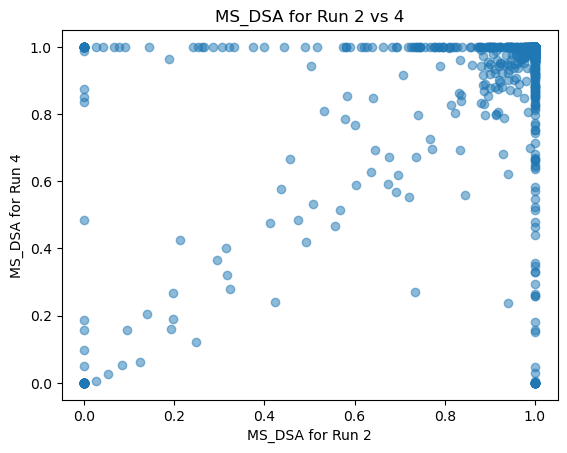

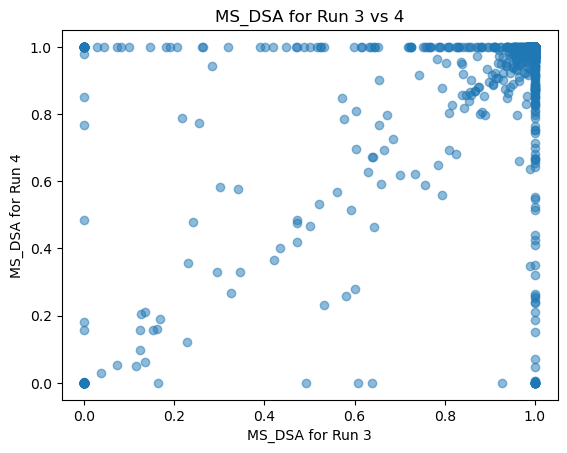

In [17]:
import numpy as np
def consitency_between_runs(ms_dsa1, ms_dsa2, run_index1: int=None, run_index2: int=None):
    ms_dsa1 = ms_dsa1[ms_dsa1["skipped"] == False]
    ms_dsa2 = ms_dsa2[ms_dsa2["skipped"] == False]
    ms_dsa1.rename(columns={"MS_DSA": f"MS_DSA_{run_index1}"}, inplace=True)
    ms_dsa2.rename(columns={"MS_DSA": f"MS_DSA_{run_index2}"}, inplace=True)
    ms_dsa = ms_dsa1.merge(ms_dsa2, on=["peptide_seq"], how="inner")
    plt.scatter(ms_dsa[f"MS_DSA_{run_index1}"].values, ms_dsa[f"MS_DSA_{run_index2}"].values, alpha=0.5)
    plt.title(f"MS_DSA for Run {run_index1} vs {run_index2}")
    plt.xlabel(f"MS_DSA for Run {run_index1}")
    plt.ylabel(f"MS_DSA for Run {run_index2}")
    plt.show()
    
run_indices = np.sort(list(binding_interface_eval.run_indices))
for run_index1 in run_indices:
    ms_dsa1 = binding_interface_eval.ms_dsa_by_run[run_index1]
    for run_index2 in range(run_index1+1, len(run_indices)):
        ms_dsa2 = binding_interface_eval.ms_dsa_by_run[run_index2]
        consitency_between_runs(ms_dsa1, ms_dsa2, run_index1=run_index1, run_index2=run_index2)


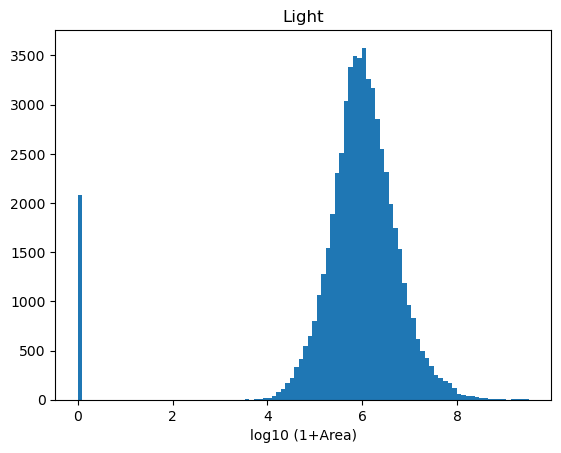

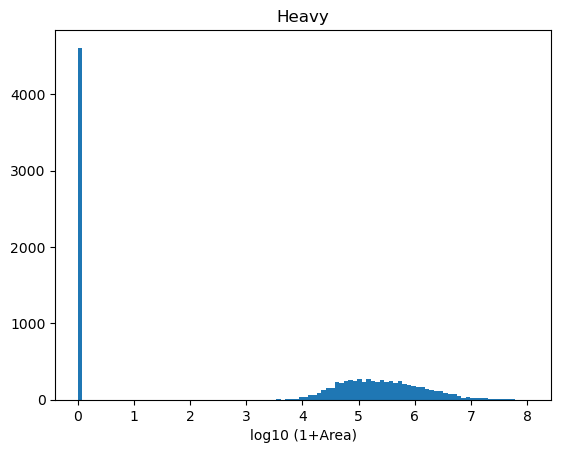

In [3]:
import numpy as np
light_area = np.array(ms_dsa.light_areas)
heavy_area = np.array(ms_dsa.heavy_areas)
from matplotlib import pyplot as plt
plt.hist(np.log10(1+light_area), bins=100)
plt.title("Light")
plt.xlabel("log10 (1+Area)")
plt.show()
plt.hist(np.log10(1+heavy_area), bins=100)
plt.title("Heavy")
plt.xlabel("log10 (1+Area)")
plt.show()



In [8]:
print((light_area == 0.0).sum())
print((heavy_area == 0.0).sum())
print(len(light_area))
print(len(heavy_area))


2081
4609
58570
10900


In [5]:
from dsa.binding_interfaces.mappings.uniprot_mappings import UniprotStructureMappings
from dsa.uniprot.config import ALL_UNIPROT_IDS
structure_ids = UniprotStructureMappings.structures_for_uniprot_id(ALL_UNIPROT_IDS[0], "alphafold")
print(structure_ids)


[]


In [29]:
import requests
import gzip
import xml.etree.ElementTree as ET

def get_residue_level_sifts(pdb_id):
    url = f"https://ftp.ebi.ac.uk/pub/databases/msd/sifts/xml/{pdb_id.lower()}.xml.gz"
    response = requests.get(url)
    
    # decompress and parse XML
    xml_content = gzip.decompress(response.content)
    root = ET.fromstring(xml_content)
    
    # namespace used in SIFTS XML
    ns = {'sifts': 'http://www.ebi.ac.uk/pdbe/docs/sifts/eFamily.xsd'}
    
    residue_mappings = []
    
    for entity in root.findall('.//sifts:entity', ns):
        chain_id = entity.get('entityId')  # this is the chain ID
        
        for residue in entity.findall('.//sifts:residue', ns):
            pdb_res = residue.find('sifts:crossRefDb[@dbSource="PDB"]', ns)
            unp_res = residue.find('sifts:crossRefDb[@dbSource="UniProt"]', ns)
            
            if pdb_res is not None and unp_res is not None:
                residue_mappings.append({
                    'chain_id':    chain_id,
                    'pdb_resnum':  pdb_res.get('dbResNum'),
                    'pdb_resname': pdb_res.get('dbResName'),
                    'uniprot_id':  unp_res.get('dbAccessionId'),
                    'unp_resnum':  unp_res.get('dbResNum'),
                    'unp_resname': unp_res.get('dbResName'),
                })
    
    return residue_mappings

mappings = get_residue_level_sifts("1cui")
pd.DataFrame(mappings)
for m in mappings:
    print(m)

{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'LEU', 'uniprot_id': 'P00590', 'unp_resnum': '17', 'unp_resname': 'L'}
{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'PRO', 'uniprot_id': 'P00590', 'unp_resnum': '18', 'unp_resname': 'P'}
{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'THR', 'uniprot_id': 'P00590', 'unp_resnum': '19', 'unp_resname': 'T'}
{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'SER', 'uniprot_id': 'P00590', 'unp_resnum': '20', 'unp_resname': 'S'}
{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'ASN', 'uniprot_id': 'P00590', 'unp_resnum': '21', 'unp_resname': 'N'}
{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'PRO', 'uniprot_id': 'P00590', 'unp_resnum': '22', 'unp_resname': 'P'}
{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'ALA', 'uniprot_id': 'P00590', 'unp_resnum': '23', 'unp_resname': 'A'}
{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'GLN', 'uniprot_id': 'P00590', 'unp_resnum': '24', 'unp_resname

In [7]:
from dsa.binding_interfaces.process_structure.Structure import Structure
structs = Structure.processed_structures("pdb", 6.5, lysine_only=True)
import numpy as np
count_total = 0
count_non_empty = 0
count_inter = 0
count_inter_5 = 0
count_all = 0
#'8bgv'
for s in structs:
    contacts = Structure.load_binding_interfaces(s, "pdb", 6.5, lysine_only=True)
    struct = Structure(s, "pdb")
    # struct.initialize_binding_interfaces(cutoff=5.0, lysine_only=True)
    # contacts3 = struct.chainwise_contacts()
    #contacts2 = struct.BI_extractor.custom_contact_extraction()
    len_contacts = len(contacts)
    if len_contacts == 0:
        continue
    inter_contacts = [len(contacts[c]["inter-chain"]) for c in contacts.keys()]
    all_contacts = [len(contacts[c]["all"]) for c in contacts.keys()]
    has_inter = np.max(inter_contacts)>0
    has_5_inter = np.max(inter_contacts)>5
    has_all = np.max(all_contacts)>0
    count_total += 1
    if has_inter:
        count_inter += 1
    if has_5_inter:
        count_inter_5 += 1
    if has_all:
        count_all += 1

print(f"Total: {count_total}")
print(f"Inter: {count_inter}")
print(f"Inter_5: {count_inter_5}")
print(f"All: {count_all}")


Total: 37112
Inter: 20425
Inter_5: 8898
All: 36713


In [16]:
import gemmi
name = gemmi.PolymerType.PeptideL.name
gemmi.PolymerType.__members__[name]


PolymerType.PeptideL

In [ ]:
from dsa.binding_interfaces.process_structure.Structure import Structure

In [ ]:
from dsa.binding_interfaces.mappings.uniprot_mappings import UniprotStructureMappings
structures = UniprotStructureMappings.structures_for_uniprot_id("P62805", "pdb")
print(len(structure["P62805"]))
UniprotStructureMappings.plot_structure_stats(xlim=(0, 100))
uniprot_to_structure_ids = UniprotStructureMappings.representative_ids(structure_db="pdb", save=False, from_saved_file=True)
print(uniprot_to_structure_ids)

AttributeError: type object 'UniprotStructureMappings' has no attribute 'get_structures'

In [ ]:
from dsa.ms_dsa.Evaluation.binding_interface_eval import BIEvaluation
binding_interface_eval = BIEvaluation()
#binding_interface_eval.plot_boxplot()

binding_interface_eval.plot_dsa_vs_sasa_with_binding_annotation(sasa_type="asa", statistic="max")
binding_interface_eval.plot_dsa_vs_sasa_binding_interface_eval.plot_dsa_vs_sasa_with_binding_annotation(sasa_type="asa", statistic="avg")with_binding_annotation(sasa_type="rel_asa", statistic="avg")
binding_interface_eval.plot_dsa_vs_sasa_with_binding_annotation(sasa_type="rel_asa", statistic="max")

/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/process_structure/structure_alignment.py:24: DtypeWarning: Columns (0: PDB_END) have mixed types. Specify dtype option on import or set low_memory=False.
  SIFT_Mapping_Table = pd.read_csv(SIFT_PDB_to_uniprot_file, sep="\t", comment="#")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/ms_dsa/Evaluation/binding_interface_eval.py:77: UserWarning: SASA not found for uniprot_id Q9BQE4
  warnings.warn(f"SASA not found for uniprot_id {uniprot_id}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/ms_dsa/Evaluation/binding_interface_eval.py:81: UserWarning: SASA sequence consistency not found for uniprot_id Q15149
  warnings.warn(f"SASA sequence consistency not found for uniprot_id {uniprot_id}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/ms_dsa/Evaluation/binding_interface_eval.py:81: UserWarning: SASA sequence consistency not found for uniprot_id Q14669
  warnings.warn(f"SASA sequence consistency not found for un

AttributeError: 'BIEvaluation' object has no attribute 'combined_df'

In [2]:
from matplotlib import pyplot as plt

def plot_dsa_vs_sasa_with_binding_annotation(ms_dsa, sasa_type: str="asa", statistic: str="avg"):
        sasa_column = f"{sasa_type}_{statistic}"
        inter = ms_dsa[ms_dsa["is_inter_chain_contacts"]]
        print(f"Inter: {inter.shape}")
        print(f"% of Inter less than 0.9: {len(inter[inter['MS_DSA'] < 0.9]) / len(inter)}")
        #not_inter = self.combined_df[~self.combined_df["is_inter_chain_contacts"]]
        intra = ms_dsa[ms_dsa["is_intra_chain_contacts"]]
        print(f"Intra: {intra.shape}")
        print(f"% of Intra less than 0.9: {len(intra[intra['MS_DSA'] < 0.9]) / len(intra)}")
        not_contact =  ms_dsa[~ms_dsa["is_inter_chain_contacts"] & ~ms_dsa["is_intra_chain_contacts"]]
        print(f"Not Contact: {not_contact.shape}")
        print(f"% of Not Contact less than 0.9: {len(not_contact[not_contact['MS_DSA'] < 0.9]) / len(not_contact)}")
        plt.scatter(not_contact["MS_DSA"].values, not_contact[sasa_column].values, color="black", label="Not Contact", s=10, alpha=0.5)
        # plt.scatter(not_inter["MS_DSA"].dropna().values, not_inter["RelASA"].dropna().values, color="black", label="Not Inter")
        plt.scatter(intra["MS_DSA"].values, intra[sasa_column].values, color="green", label="Intra", s=10, alpha=0.5)
        # plt.scatter(not_intra["MS_DSA"].dropna().values, not_intra["RelASA"].dropna().values, color="black", label="Not Intra")
        plt.scatter(inter["MS_DSA"].values, inter[sasa_column].values, color="red", label="Inter", s=10, alpha=0.5)
        plt.xlabel("MS_DSA")
        plt.ylabel(sasa_column)
        plt.title(f"MS_DSA vs {sasa_column}")
        plt.legend()
        plt.show()

Inter: (2735, 15)
% of Inter less than 0.9: 0.11407678244972577
Intra: (7952, 15)
% of Intra less than 0.9: 0.130658953722334
Not Contact: (10811, 15)
% of Not Contact less than 0.9: 0.15077236148367404


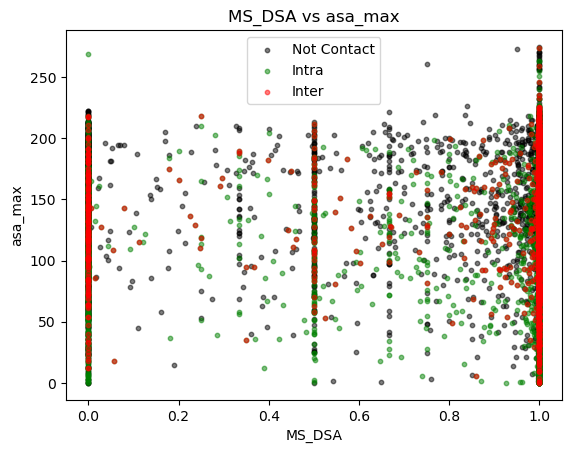

Inter: (2735, 15)
% of Inter less than 0.9: 0.11407678244972577
Intra: (7952, 15)
% of Intra less than 0.9: 0.130658953722334
Not Contact: (10811, 15)
% of Not Contact less than 0.9: 0.15077236148367404


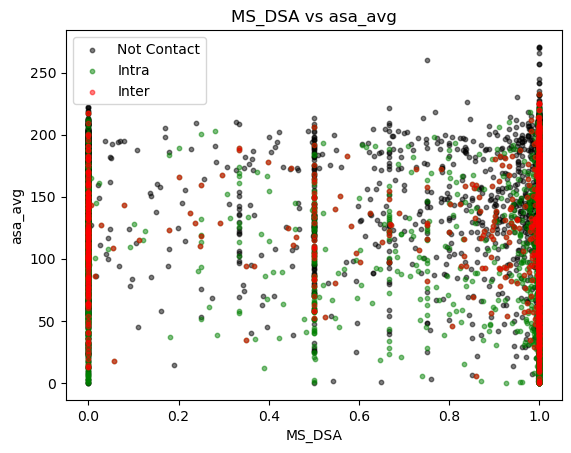

Inter: (2735, 15)
% of Inter less than 0.9: 0.11407678244972577
Intra: (7952, 15)
% of Intra less than 0.9: 0.130658953722334
Not Contact: (10811, 15)
% of Not Contact less than 0.9: 0.15077236148367404


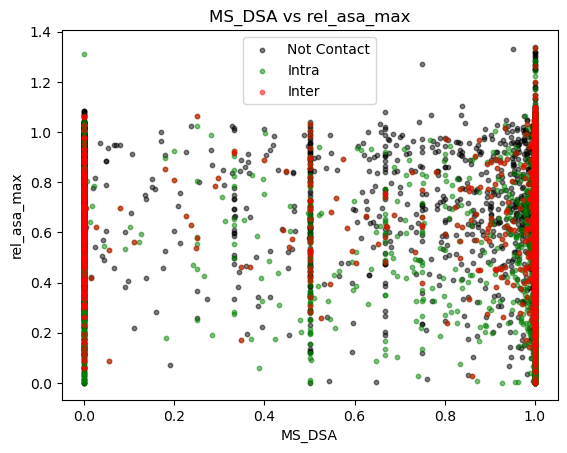

TypeError: plot_dsa_vs_sasa_with_binding_annotation() missing 1 required positional argument: 'ms_dsa'

In [4]:
ms_dsa = binding_interface_eval.ms_dsa
plot_dsa_vs_sasa_with_binding_annotation(ms_dsa, sasa_type="asa", statistic="max")
plot_dsa_vs_sasa_with_binding_annotation(ms_dsa, sasa_type="asa", statistic="avg")
plot_dsa_vs_sasa_with_binding_annotation(ms_dsa, sasa_type="rel_asa", statistic="max")
plot_dsa_vs_sasa_with_binding_annotation(sasa_type="rel_asa", statistic="max")

In [5]:
import pandas as pd
from dsa.config import DATA_DIR
sasa_df = pd.read_csv(DATA_DIR / "sasa" / "afold.csv")
print(sasa_df.columns)
#print(sasa_df.head())
print(sasa_df.shape)
print(sasa_df.Sequence.nunique())
print(sasa_df.Keys)


Index(['Unnamed: 0', 'seqcharge', 'Protein.Group',
       '2026-05-01_SS_CPP_argC-200ng_1hr_1',
       '2026-05-01_SS_CPP_argC-200ng_1hr_2',
       '2026-05-01_SS_CPP_argC-200ng_1hr_3',
       '2026-05-01_SS_CPP_argC-200ng_1hr_4', 'mean', 'std', 'cv', 'Sequence',
       'Keys', 'Position Start', 'Position End', 'Position K', 'asa',
       'K_count', 'ASync AA', 'pLDDT', 'RelASA', '2 Structure', 'Disorder',
       'Surface', 'dssp-key', 'NASA'],
      dtype='str')
(1118, 25)
1064
0       sp|Q8TAP8|PPR35_HUMAN
1        sp|Q13573|SNW1_HUMAN
2        sp|Q9Y5K8|VATD_HUMAN
3       sp|P04083|ANXA1_HUMAN
4       sp|P04083|ANXA1_HUMAN
                ...          
1113     sp|O75369|FLNB_HUMAN
1114     sp|P21333|FLNA_HUMAN
1115     sp|P21333|FLNA_HUMAN
1116    sp|Q12931|TRAP1_HUMAN
1117     sp|O94925|GLSK_HUMAN
Name: Keys, Length: 1118, dtype: str


In [1]:
from dsa.binding_interfaces.binding_interfaces import BindingInterfaces
from dsa.binding_interfaces.process_structure.Structure import Structure
structures = ['7OI6', '9UU7']
uniprot_id = "Q9NUL7"
# BI = BindingInterfaces("Q9NUL7", structure_db="pdb", cutoff=5.0, lysine_only=True)
# BI.build_interfaces()
struct = Structure('7OI6')
struct.initialize_binding_interfaces(cutoff=6.5, lysine_only=True)


/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/process_structure/structure_alignment.py:24: DtypeWarning: Columns (0: PDB_END) have mixed types. Specify dtype option on import or set low_memory=False.
  SIFT_Mapping_Table = pd.read_csv(SIFT_PDB_to_uniprot_file, sep="\t", comment="#")


Using biological assembly: '1'
Number of biologically relevant contact pairs: 0


In [1]:
from dsa.binding_interfaces.structure.structure import Structure, PDBStructure
st = PDBStructure("6v2h")



Using biological assembly: '1'


In [11]:
import gemmi
model = st.structure[0]
print(type(model))
print(dir(model))
for sub in model.subchains():
    # print(sub)
    # print(dir(sub))
    #print(sub[0].subchain)
    print(sub.subchain_id())
    #print(dir(sub.subchain_id))
    print(sub.auth_seq_id_to_label(sub[0].seqid))
    break

print(dir(sub[0]))

print([type(seq) for seq in model[0].get_polymer().extract_sequence()])
print(sub.check_polymer_type())
print(dir(gemmi))

info = gemmi.find_tabulated_residue(sub[0].name)
print(dir(info))
info.kind

<class 'gemmi.Model'>
['__class__', '__delattr__', '__delitem__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', 'add_chain', 'all', 'calculate_b_aniso_range', 'calculate_b_iso_range', 'calculate_center_of_mass', 'calculate_mass', 'clone', 'count_atom_sites', 'count_occupancies', 'find_chain', 'find_cra', 'find_last_chain', 'find_residue_group', 'get_all_residue_names', 'get_subchain', 'has_hydrogen', 'iterator', 'num', 'remove_alternative_conformations', 'remove_chain', 'remove_hydrogens', 'remove_ligands_and_waters', 'remove_waters', 'sole_residue', 'split_chains_by_segments', 'subchains', 'transform_pos_and_adp']
A
1
['__class__', '__contains__', '__delattr__', '__delitem__', 

ResidueKind.AA

In [1]:

from dsa.binding_interfaces.contacts.structure_contacts import StructureContactsStore, StructureContacts
#from dsa.binding_interfaces.contacts.filters import lysine_only_filter
store = StructureContactsStore(database="pdb", distance_cutoff=6.5, contact_filter_key="lysine_only")
contacts = store.load("9csl")
print([c.structure for c in contacts.contacts])
#len(contacts.contacts)


Using biological assembly: '1'
[<dsa.binding_interfaces.structure.structure.PDBStructure object at 0x7f66ca3c92b0>, <dsa.binding_interfaces.structure.structure.PDBStructure object at 0x7f66ca3c92b0>, <dsa.binding_interfaces.structure.structure.PDBStructure object at 0x7f66ca3c92b0>, <dsa.binding_interfaces.structure.structure.PDBStructure object at 0x7f66ca3c92b0>, <dsa.binding_interfaces.structure.structure.PDBStructure object at 0x7f66ca3c92b0>, <dsa.binding_interfaces.structure.structure.PDBStructure object at 0x7f66ca3c92b0>, <dsa.binding_interfaces.structure.structure.PDBStructure object at 0x7f66ca3c92b0>, <dsa.binding_interfaces.structure.structure.PDBStructure object at 0x7f66ca3c92b0>, <dsa.binding_interfaces.structure.structure.PDBStructure object at 0x7f66ca3c92b0>, <dsa.binding_interfaces.structure.structure.PDBStructure object at 0x7f66ca3c92b0>, <dsa.binding_interfaces.structure.structure.PDBStructure object at 0x7f66ca3c92b0>, <dsa.binding_interfaces.structure.structure.

In [2]:
print([type(c.chain1) for c in contacts.contacts])

[<class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'gemmi.Chain'>, <class 'ge

In [10]:
# for seq, df in sasa_df.groupby(["Sequence", "Keys"]):
#     # print(seq)
#     # print(df.shape)
#     if df.shape[0] > 1:
#         print(df.RelASA)

df = sasa_df[["Sequence", "Keys", "RelASA"]].groupby(["Sequence", "Keys"]).agg({"RelASA": "mean"})
print(df.head())

                                                 RelASA
Sequence                Keys                           
AAAGSHFDAAKAVEEQLR      sp|Q8TAP8|PPR35_HUMAN  0.556522
AADKLAPAQYIR            sp|Q13573|SNW1_HUMAN   0.873913
AAGEVLEPANLLAEEKDEDLLFE sp|Q9Y5K8|VATD_HUMAN   0.839130
AAMKGLGTDEDTLIEILASR    sp|P04083|ANXA1_HUMAN  0.647826
AAQLQHSEKMAQYLEEER      sp|Q16204|CCDC6_HUMAN  0.465217


In [ ]:
from dsa.binding_interfaces.process_structure.Structure import Structure
from dsa.binding_interfaces.process_structure.structure_alignment import StructureAlignment
st = Structure("6v2h")
st.structure[0][0]
{c.name: len([r for r in c]) for c in st.structure[0]}    
all = StructureAlignment('2v89')


{'A': 62,
 'B': 12,
 'C': 62,
 'D': 10,
 'E': 73,
 'F': 10,
 'G': 64,
 'H': 12,
 'I': 62,
 'J': 12,
 'K': 60,
 'L': 10}

In [18]:
import rust_sasa_python as sasa
from dsa.binding_interfaces.config import PDB_DIR
structure_path = PDB_DIR / ("9BQ2".lower()+".cif")
#print(dir(sasa))
result = sasa.calculate_residue_sasa(structure_path.as_posix())

# print(f"Total SASA: {result.total:.2f} Å²")
print(result[0])
# per residue
# result.residues           # list of residue results
# result.per_residue        # or this

# for r in result.residues:
#     print(r.name, r.chain, r.seqid, r.sasa)

# # or as a dict
# residue_sasa = {(r.chain, r.seqid): r.sasa for r in result.residues}

Residue(chain_id='A', residue_name='MET', residue_number=1, sasa=210.540)


In [1]:
from dsa.binding_interfaces.binding_interfaces import BindingInterfaces
BI = BindingInterfaces(saved_binding_interfaces_only=True)
x = 0
found_misaligned = False
for unp, struct_dict in BI.is_aligned.items():
    for struct_id, is_aligned in struct_dict.items():
        if not is_aligned:
            print(unp, struct_id)
            x += 1
        if x > 10:
            found_misaligned = True
            break
    if found_misaligned:
        break





/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/binding_interfaces.py:120: SyntaxWarning: invalid decimal literal
  elif isinstance(v, list) and len(v)>0and isinstance(v[0], list) and len(v[0]) ==2:


Q04917 2C74
P31153 9QPP
Q9Y5P4 6J0O
Q9Y5P4 6IF0
Q9Y5P4 5ZYJ
P01116 6W4E
P01116 6PTS
P01116 6PTW
P01116 9BI2
P01116 8QVU
P01116 7KYZ


In [ ]:
from dsa.uniprot.uniprot_to_sequence import UniprotToSequence
from dsa.binding_interfaces.process_structure.Structure import Structure
#st = Structure('2C74')
st = Structure('6QJH')
st.initialize_binding_interfaces(cutoff=cutoff)
contact_residues = st.uniprotwise_contact_residues()

print(st.structure[0][0])

from Bio.SeqUtils import seq1

def align_sequences(pdb_seq, unp_seq, pdb_alignment, offset=0):
    pdb_seq = list(pdb_seq)
    unp_seq = list(unp_seq)
    count_match = 0
    for ix_pdb, (ix_unp, res) in enumerate(zip(pdb_alignment, unp_seq)): 
        if ix_unp is not None and 0 <= ix_unp + offset < len(unp_seq):   
            match =  unp_seq[ix_unp + offset] == res
            if match:
                pdb_seq[ix_pdb] = '_'
                unp_seq[ix_unp] = '_'
                count_match += 1
    return ''.join(pdb_seq), ''.join(unp_seq), count_match
            

for unp, ents in st.uniprot_to_entity.items():
    s1 = UniprotToSequence.get_sequence(unp)
    # print(s1)
    print(unp, ents)
    for e in ents:
        for chain in st.entity_to_chains[e]:
            chainobj = [ch for ch in st.structure[0] if ch.name == chain][0]
            s2 = ''.join([seq1(r.name) for r in chainobj])
            ix = [st.sequence_aligner[chain].map(i) for i in range(1,len(s2)+1)]
            print(ix)
            print('Uniprot sequence: ', s1)
            print('PDB sequence: ', s2)
            best_match = 0
            offset_best = -1
            for offset in [-1, 0, 1, 2, -2, 3, -3]:
                pdb_seq, unp_seq, match = align_sequences(s2, s1, ix, offset=offset)
                if match > best_match:
                    best_match = match
                    offset_best = offset
            pdb_seq, unp_seq, match = align_sequences(s2, s1, ix, offset=offset_best)
            print('pdb_seq: ', pdb_seq)
            print('unp_seq: ', unp_seq)
            print('match: ', match)
            print('offset_best: ', offset_best)
            
 


         


<gemmi.Chain A with 59 res>
P10636 ['1']
[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]
Uniprot sequence:  MAEPRQEFEVMEDHAGTYGLGDRKDQGGYTMHQDQEGDTDAGLKESPLQTPTEDGSEEPGSETSDAKSTPTAEDVTAPLVDEGAPGKQAAAQPHTEIPEGTTAEEAGIGDTPSLEDEAAGHVTQEPESGKVVQEGFLREPGPPGLSHQLMSGMPGAPLLPEGPREATRQPSGTGPEDTEGGRHAPELLKHQLLGDLHQEGPPLKGAGGKERPGSKEEVDEDRDVDESSPQDSPPSKASPAQDGRPPQTAAREATSIPGFPAEGAIPLPVDFLSKVSTEIPASEPDGPSVGRAKGQDAPLEFTFHVEITPNVQKEQAHSEEHLGRAAFPGAPGEGPEARGPSLGEDTKEADLPEPSEKQPAAAPRGKPVSRVPQLKARMVSKSKDGTGSDDKKAKTSTRSSAKTLKNRPCLSPKHPTPGSSDPLIQPSSPAVCPEPPSSPKYVSSVTSRTGSSGAKEMKLKGADGKTKIATPRGAAPPGQKGQANATRIPAKTPPAPKTPPSSGEPPKSGDRSGYSSPGSPGTPGSRSRTPSLPTPPTREPKKVAVVRTPPKSPSSAKSRLQTAPVPMPDLKNVKSKIGSTENLKH

In [7]:
from dsa.uniprot.uniprot_to_sequence import UniprotToSequence
from dsa.binding_interfaces.process_structure.Structure import Structure
#st = Structure('2C74')
st = Structure('6QJH')
names = []
for model in st.structure:
    for chain in model:
        for res in chain:
            for atom in res:
                if atom.name == 'NZ':
                    names.append(f"{res.name}-{atom.name}")
names = set(names)
names = list(names)
print(names)


        


['LYS-NZ']


In [3]:
print(dir(res))


['__class__', '__contains__', '__delattr__', '__delitem__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', 'add_atom', 'clone', 'entity_id', 'entity_type', 'find_atom', 'first_conformer', 'flag', 'get_ca', 'get_p', 'het_flag', 'is_water', 'label_seq', 'name', 'recommended_het_flag', 'remove_atom', 'remove_hydrogens', 'segment', 'seqid', 'sifts_unp', 'sole_atom', 'subchain', 'trim_to_alanine']


In [1]:
from dsa.uniprot.config import ALL_UNIPROT_IDS, example_uniprot_id
from dsa.binding_interfaces.binding_interfaces import BindingInterfaces
from dsa.binding_interfaces.mappings.uniprot_mappings import UniprotStructureMappings
#uniprot_to_structure_ids = UniprotStructureMappings.get_structures(ALL_UNIPROT_IDS, "pdb", remove_ids_with_structure_ids=True)
#uniprot_id = list(uniprot_to_structure_ids.keys())[0]
uniprot_id = "P69891"
uniprot_id = "A0A672GII6"
uniprot_id = "P62805"
BI = BindingInterfaces([uniprot_id])



Processed 500 structures
Total processed 495 structures including saved ones
Total number of structure-protein pairs: 1340
Total number of unaligned structure-protein pairs: 2249


In [ ]:
BI.binding_interface(uniprot_id)

In [ ]:
print(len(uniprot_to_structure_ids.keys()))
print(len(ALL_UNIPROT_IDS))

In [ ]:
from dsa.ppi_binding_interfaces.config import test_cif_file
import gemmi
gemmi.cif.read(test_cif_file.as_posix())

In [ ]:
str(test_cif_file)

In [ ]:
from dsa.ppi_binding_interfaces.mappings.uniprot_mappings import remove_invalid_entries, get_mapped_uniprot_ids
keys = get_mapped_uniprot_ids("pdb")

In [ ]:
import numpy as np
lens = np.array([len(k.split(";")) for k in keys])

np.sum(lens==1)

In [ ]:
import dill
pair = dill.load(open("/data/dbs/dips_pdb/cc/3ccm.pdb1_2.dill", "rb"))

In [ ]:
dir(pair)

In [ ]:
id = '1tue'
s = "SGSNMSQWIRFRCSKIDEGGDWRPIVQFLRYQQIEFITFLGALKSFLKGTPKKNCLVFCGPANTGKSYFGMSFIHFIQGAVISFVNSTSHFWLEPLTDTKVAMLDDATTTCWTYFDTYMRNALDGNPISIDPLIQLKCPPILLTTNIHPAKDNRWPYLESRITVFEFPNAFPFDKNGNPVYEINDKNWKCFFERTWSRLDL"
from dsa.dips.mapping.get_sifts_data import pdb_sequence_to_uniprot
pdb_sequence_to_uniprot(id, s)


In [ ]:
from dsa.ppi_binding_interfaces.uniprot_to_pdb import get_pdb_ids_from_rcsb, download_structures_for_uniprot
print(get_pdb_ids_from_rcsb("Q5VSL9", include_computational_models=True))  # e.g. ['7K36']
download_structures_for_uniprot("Q5VSL9")

In [ ]:
row = df.iloc[0]
seq_a = row["seq_a"]
seq_b = row["seq_b"]

# Load contact map
cmap = np.load(row["contact_map"])  # shape: (L_A, L_B)

# Interface residues = any residue with at least one contact
interface_A = np.where(cmap.sum(axis=1) > 0)[0]  # indices in chain A
interface_B = np.where(cmap.sum(axis=0) > 0)[0]  # indices in chain B

# Get the actual amino acids at the interface
interface_seq_A = [seq_a[i] for i in interface_A]
interface_seq_B = [seq_b[j] for j in interface_B]

print(f"Chain A interface residues: {interface_A}")
print(f"Chain B interface residues: {interface_B}")
print(f"Interface fraction A: {len(interface_A)/len(seq_a):.2%}")
print(f"Interface fraction B: {len(interface_B)/len(seq_b):.2%}")

In [1]:
from dsa.uniprot.config import ALL_UNIPROT_IDS
from dsa.binding_interfaces.binding_interfaces import BindingInterfacesStore, UniprotStructureMappingsStore
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")

avg_nz_prop_per_uniprot = {}
max_nz_prop_per_uniprot = {}
nz_prop_per_structure_per_uniprot = {}
zero_structure_count = 0
no_binding_interface_count = 0
print_interval = 25
for i, unp in enumerate(ALL_UNIPROT_IDS):
    structure_mapper = UniprotStructureMappingsStore.get_mapper(structure_db="pdb")
    structure_ids = structure_mapper.structures_for_uniprot_id(unp)
    if len(structure_ids) == 0:
        zero_structure_count += 1
        continue
    binding_interfaces = BindingInterfacesStore(structure_db="pdb", cutoff=6.5, lysine_only=True).load(unp)
    if binding_interfaces is None:
        no_binding_interface_count += 1
        continue
    if i % print_interval == 0:
        print(f"Processing {i} of {len(ALL_UNIPROT_IDS)}")
    avg_nz_prop, max_nz_prop, nz_prop_per_structure = binding_interfaces.lysine_nz_proportion_in_structures()
    avg_nz_prop_per_uniprot[unp] = avg_nz_prop
    max_nz_prop_per_uniprot[unp] = max_nz_prop
    nz_prop_per_structure_per_uniprot[unp] = nz_prop_per_structure
plt.hist(list(avg_nz_prop_per_uniprot.values()), bins=100)
plt.show()  
plt.hist(list(max_nz_prop_per_uniprot.values()), bins=100)
plt.show()




ModuleNotFoundError: No module named 'dsa.binding_interfaces.process_structure'

In [1]:
from dsa.binding_interfaces.structure_uniprot_alignment.aligner import StructureSequenceAligner
from dsa.binding_interfaces.structure.structure import Structure
from dsa.binding_interfaces.factory import ClassFactory
structure_id = "2jrz"  
structure_id = "5a2q"
st = ClassFactory.create(interface = Structure, key = "pdb", structure_id = structure_id)
aligner = ClassFactory.create(interface = StructureSequenceAligner, key = "pdb", structure_id = structure_id, structure_model = st.model, uniprot_to_entity = st.uniprot_to_entities)
#aligner.get_chains_containing_uniprot_id(aligner.uniprot_ids[0])
#aligner._generate_mappings(chain = "X", uniprot_id = "P63220")

Using biological assembly: '1'


ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
from dsa.binding_interfaces.structure_uniprot_alignment.pdb_aligner import PDBSequenceAligner
PDBSequenceAligner.download_mappings('5a2q')

In [12]:
#mapping = aligner._generate_mapping_pdbe(chain = "X", uniprot_id = "P63220")
mappings = aligner.generate_mappings()


In [5]:
from dsa.binding_interfaces.mappings.uniprot_mappings import UniprotStructureMappingsStore
mappings = UniprotStructureMappingsStore.get_mapper("pdb")
structures = mappings.get_mapped_structures()
print(len(structures))



37744


In [2]:
unp = aligner.uniprot_ids[0]
chain = aligner.chains_containing_uniprot_id(unp)[0]
seq_dict = st.model.get_chain_sequence_as_dict(chain)
print(aligner.mappings)
res = list(seq_dict.items())[10]
print(res)
print(aligner.map(chain, res, unp))




defaultdict(<function StructureSequenceAligner.generate_mappings.<locals>.<lambda> at 0x7f6119920040>, {'A': defaultdict(<class 'dict'>, {'P41229': defaultdict(tuple[int, str], {('3', 'N'): (73, 'N'), ('4', 'E'): (74, 'E'), ('5', 'L'): (75, 'L'), ('6', 'E'): (76, 'E'), ('7', 'A'): (77, 'A'), ('8', 'Q'): (78, 'Q'), ('9', 'T'): (79, 'T'), ('10', 'R'): (80, 'R'), ('11', 'V'): (81, 'V'), ('12', 'K'): (82, 'K'), ('13', 'L'): (83, 'L'), ('14', 'N'): (84, 'N'), ('15', 'Y'): (85, 'Y'), ('16', 'L'): (86, 'L'), ('17', 'D'): (87, 'D'), ('18', 'Q'): (88, 'Q'), ('19', 'I'): (89, 'I'), ('20', 'A'): (90, 'A'), ('21', 'K'): (91, 'K'), ('22', 'F'): (92, 'F'), ('23', 'W'): (93, 'W'), ('24', 'E'): (94, 'E'), ('25', 'I'): (95, 'I'), ('26', 'Q'): (96, 'Q'), ('27', 'G'): (97, 'G'), ('28', 'S'): (98, 'S'), ('29', 'S'): (99, 'S'), ('30', 'L'): (100, 'L'), ('31', 'K'): (101, 'K'), ('32', 'I'): (102, 'I'), ('33', 'P'): (103, 'P'), ('34', 'N'): (104, 'N'), ('35', 'V'): (105, 'V'), ('36', 'E'): (106, 'E'), ('37',

In [1]:
from dsa.binding_interfaces.contacts.protein_contacts import ProteinContacts
unp = 'P62266'
contacts = ProteinContacts(uniprot_id = unp, structure_database = "pdb", distance_cutoff = 6.5, contact_filter_key = "lysine_only")



/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/pdb_aligner.py:31: DtypeWarning: Columns (0: PDB_END) have mixed types. Specify dtype option on import or set low_memory=False.
  SIFT_Mapping_Table = pd.read_csv(SIFT_PDB_to_uniprot_file, sep="\t", comment="#")


Using biological assembly: '1'
Using biological assembly: '1'
Using biological assembly: '1'
Using biological assembly: '1'
Using biological assembly: '1'
Using biological assembly: '1'
Found contacts in the same chain as the uniprot id
Using biological assembly: '1'
Using biological assembly: '1'
Found contacts in the same chain as the uniprot id
Using biological assembly: '1'
Using biological assembly: '1'
Found contacts in the same chain as the uniprot id
Using biological assembly: '1'
Using biological assembly: '1'
Using biological assembly: '1'
Found contacts in the same chain as the uniprot id
Using biological assembly: '1'
Found contacts in the same chain as the uniprot id
Using biological assembly: '1'
Found contacts in the same chain as the uniprot id
Using biological assembly: '1'
Found contacts in the same chain as the uniprot id
Using biological assembly: '1'


/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'ARG')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'LEU')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'SER')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'ALA')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268:

Found contacts in the same chain as the uniprot id
Using biological assembly: '1'


/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'ARG')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'LEU')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'SER')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'ALA')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268:

...

/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'MET')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'THR')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'LYS')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'VAL')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268:

Using biological assembly: '1'
Using biological assembly: '1'


/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'MET')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'THR')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'LYS')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268: UserWarning: Invalid residue id: (nan, 'VAL')
  warnings.warn(f"Invalid residue id: {residue_in_structure}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/aligner.py:268:

Using biological assembly: '1'
Using biological assembly: '1'
Using biological assembly: '1'
Found contacts in the same chain as the uniprot id
Using biological assembly: '1'
Found contacts in the same chain as the uniprot id
Using biological assembly: '1'
Found contacts in the same chain as the uniprot id
Using biological assembly: '1'
Found contacts in the same chain as the uniprot id
Using biological assembly: '1'
Found contacts in the same chain as the uniprot id
Using biological assembly: '1'
Found contacts in the same chain as the uniprot id
Using biological assembly: '1'
Using biological assembly: '1'
Using biological assembly: '1'
Found contacts in the same chain as the uniprot id
Using biological assembly: '1'
Error decompressing 8uik: Not a gzipped file (b'<!')


ValueError: No mapping resource available

In [3]:
import gemmi
gemmi.Block


AttributeError: module 'gemmi' has no attribute 'Block'